In [1]:
from api import FaceAlignment
import torch
from torchvision.io import read_video, write_video
fa = FaceAlignment()

Loading pretrained model from c:\Users\Cevan\Documents\GitHub\face-alignment\face_alignment\detection\retina\weights\mobilenet0.25_Final.pth
remove prefix 'module.'
Missing keys:0
Unused checkpoint keys:0
Used keys:300


In [2]:
vid = read_video('../musko.mp4', output_format="TCHW")[0][:40]
print(vid.shape)

c:\venv\TorchStandard\Lib\site-packages\torchvision\io\_video_deprecation_warning.py:5: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(
c:\venv\TorchStandard\Lib\site-packages\torchvision\io\video.py:199: UserWarning: The pts_unit 'pts' gives wrong results. Please use pts_unit 'sec'.
  warnings.warn("The pts_unit 'pts' gives wrong results. Please use pts_unit 'sec'.")


torch.Size([40, 3, 1080, 1920])


In [3]:
cr, ldmk = fa.sample_crop_csr(vid, batch_size=4)

Crop-Sampling CSR: 100%|██████████| 10/10 [00:03<00:00,  3.22it/s]


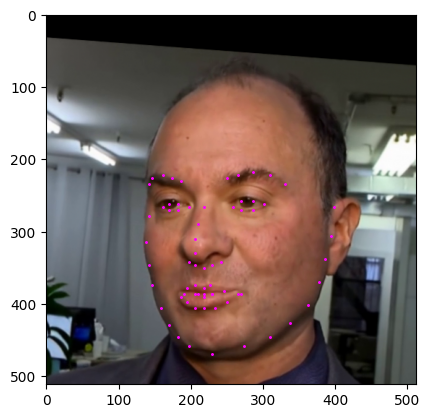

In [19]:
from matplotlib import pyplot as plt
idx = 60
ldm = ldmk[idx].cpu().numpy()
plt.imshow(cr[idx].permute(1, 2, 0).cpu().numpy()/255)
plt.scatter(ldm[:, 0], ldm[:, 1], s=5, c='magenta', marker='.')

In [ ]:
# =========================================================================

In [2]:
vid = read_video('../musko.mp4', output_format="TCHW")[0][120:124]

def resize_video(video, max_resolution):
    scale_factor = max_resolution / max(video.shape[2], video.shape[3])
    resized = torch.nn.functional.interpolate(
        video.float(), scale_factor=scale_factor, mode='bilinear', align_corners=False
    ).to(video.dtype)
    return resized, scale_factor
vid, scale_factor = resize_video(vid, 1280)

c:\venv\TorchStandard\Lib\site-packages\torchvision\io\_video_deprecation_warning.py:5: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(
c:\venv\TorchStandard\Lib\site-packages\torchvision\io\video.py:199: UserWarning: The pts_unit 'pts' gives wrong results. Please use pts_unit 'sec'.
  warnings.warn("The pts_unit 'pts' gives wrong results. Please use pts_unit 'sec'.")


In [ ]:
boxes, eyes = fa.detect_faces(vid)
cropped_256 = fa.sample_crop(vid, boxes, size=(256, 256))
lds = fa.detect_landmarks(cropped_256)


    
left_eye = eyes[:, 0, :]
right_eye = eyes[:, 1, :]

eye_vector = right_eye - left_eye
angles_rad = torch.arctan2(eye_vector[:, 1], eye_vector[:, 0]) * -1


Crop-Sampling: 100%|██████████| 1/1 [00:00<00:00, 68.99it/s]


[INFO] Crop-Sampling time: 0.0176 seconds
[INFO] Landmark Detect time: 0.0588 seconds


In [4]:
def crops(frames, centers, scales, rotations, out_size=512):
    """
    Crops and rotates videos around center points with given scale and rotation (square crop).
    
    Args:
        frames: (N, 3, H, W) 
        centers: (N, 2) in (x, y) format 
        scales: (N,)  - scale factor for square crop size
        rotations: (N,) - rotation in radians, counterclockwise
        out_size: int - output size (default 512)
    
    Returns:
        cropped: (N, 3, out_size, out_size) 
    """
    N, C, H, W = frames.shape
    device = frames.device
    dtype = frames.dtype

    # Normalize center
    center_x = (centers[:, 0] / (W - 1)) * 2 - 1  # (N,)
    center_y = (centers[:, 1] / (H - 1)) * 2 - 1  # (N,)
    # center = torch.stack([center_x, center_y], dim=1)  # (N, 2)

    # Scaling factors
    scale = scales.view(-1, 1)  # (N, 1)
    scale_x = (scale[:, 0] * out_size) / (W - 1)  # (N,)
    scale_y = (scale[:, 0] * out_size) / (H - 1)  # (N,)

    # Create base grid (normalized coordinates in [-1, 1])
    grid_y, grid_x = torch.meshgrid(
        torch.linspace(-1, 1, out_size, device=device, dtype=dtype),
        torch.linspace(-1, 1, out_size, device=device, dtype=dtype),
        indexing='ij'
    )
    base_grid = torch.stack((grid_x, grid_y), dim=-1)  # (H, W, 2)
    base_grid = base_grid.unsqueeze(0).repeat(N, 1, 1, 1)  # (N, H, W, 2)

    # Build rotation matrix
    sin = torch.sin(rotations).view(N, 1, 1)
    cos = torch.cos(rotations).view(N, 1, 1)
    rot_matrix = torch.stack([
        torch.stack([cos, -sin], dim=-1),  # (N, 1, 2)
        torch.stack([sin,  cos], dim=-1)
    ], dim=-2).squeeze(1)  # (N, 1, 2, 2)

    # Apply rotation
    grid = base_grid @ rot_matrix  # (N, H, W, 2)
    assert grid.shape == (N, out_size, out_size, 2), "Grid shape mismatch"

    # Apply scaling
    grid[..., 0] = grid[..., 0] * scale_x[:, None, None] + center_x[:, None, None]
    grid[..., 1] = grid[..., 1] * scale_y[:, None, None] + center_y[:, None, None]

    # Sample using grid_sample
    cropped = torch.nn.functional.grid_sample(
        frames, grid, mode='bilinear', padding_mode='zeros', align_corners=True
    )
    return cropped, rot_matrix.squeeze()

In [20]:
batch = vid.to("cuda", dtype=torch.float32)
x1, y1, x2, y2 = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
centers = torch.stack([x2 - (x2 - x1) * 0.5, y2 - (y2 - y1) * 0.62]).permute(1, 0)
scales = (x2 - x1 + y2 - y1) / 256
cropped_256, rot = crops(batch, centers, scales, angles_rad, out_size=256)

# detect landmarks on cropped frames
lds = fa.detect_landmarks(cropped_256)

# 512
cropped_512, rot = crops(batch, centers, scales / 2, angles_rad, out_size=512)

[INFO] Landmark Detect time: 0.0614 seconds


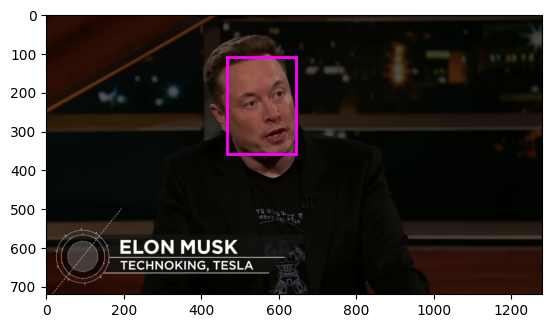

In [64]:
from matplotlib import pyplot as plt
import matplotlib.patches as patches
plt.imshow(vid[0].cpu().permute(1, 2, 0))

display_id = 0
x1, y1, x2, y2 = boxes[display_id].cpu()
h, w = y2 - y1, x2 - x1
rect = patches.Rectangle((x1, y1), w, h, linewidth=2, edgecolor='magenta', facecolor='none')
plt.gca().add_patch(rect)

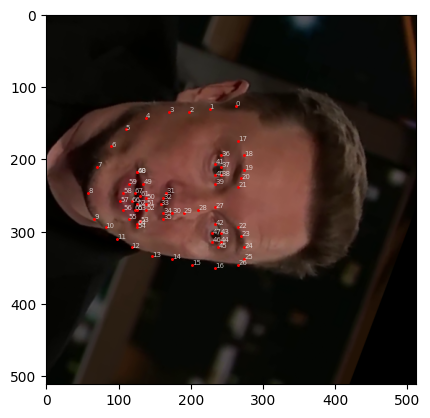

In [21]:
from matplotlib import pyplot as plt
plt.imshow(cropped_512[0].cpu().permute(1, 2, 0)/255)

# ld_rot = (lds * 2) @ rot.transpose(2, 1)
# ld = ld_rot.cpu()

ld = lds.cpu() * 2

# OUTLINE_IDX = list(range(17))
# LEFT_EYEBROW_IDX = list(range(17, 22))
# RIGHT_EYEBROW_IDX = list(range(22, 27))
# NOSE_IDX = list(range(27, 36))
# LEFT_EYE_IDX = list(range(36, 42))
# RIGHT_EYE_IDX = list(range(42, 48))
# MOUTH_IDX = list(range(48, 68))

plt.scatter(ld[0, :, 0], ld[0, :, 1], s=5, c='red', marker='.')
for i in range(ld.shape[1]):
    plt.annotate(str(i), xy=(ld[0, i, 0], ld[0, i, 1]), color="white", alpha=0.7, fontsize=5)

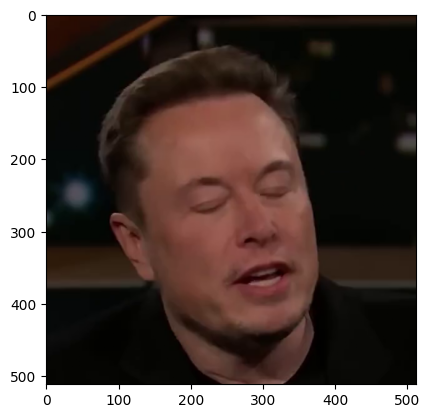

In [6]:
from matplotlib import pyplot as plt
plt.imshow(cropped[0].cpu().permute(1, 2, 0)/255)